# YYW 55A, 55B, and 55C fit comparison and physical consistency checks

This notebook follows the information flow from the measured scattering curves to the fitted random-wave parameters, line-length densities, coherent-SLD contrast, effective cross-sectional areas, nominal-composition volume fractions, and finally the static real-space renderings. Results are reported both for the full line density $\rho_0$ (without $p_H$) and the retained visible density $p_H\rho_0$ (with $p_H$).

In [1]:
from pathlib import Path
import sys

# Ensure cf_tools resolves the scattering implementation in smpl/, as in cf.ipynb.
SMPL_DIR = Path.cwd().parent.resolve()
sys.path.insert(0, str(SMPL_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Preload the smpl implementation before the renderer adds the project root.
import rw_line_scattering as rls
import cf_tools as cf

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pv.OFF_SCREEN = True

OUTPUT_DIR = Path("output/yyw")
SAMPLE_TAGS = ("55A_R0", "55B_R0", "55C_R0")
WEIGHTFRAC_TAGS = ("0.5", "1.5", "4.5")
COLORS = {"55A_R0": "#009E73", "55B_R0": "#0072B2", "55C_R0": "#D55E00"}

## Load the saved observations, fit curves, and parameters

In [2]:
def load_named_values(path):
    table = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    return {str(row["name"]): float(row["value"]) for row in np.atleast_1d(table)}


def load_i_highq_anchor(path):
    table = np.atleast_1d(
        np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    )
    matches = table[np.asarray(table["name"], dtype=str) == "highQ_line"]
    if matches.size != 1:
        raise ValueError(f"Expected one highQ_line row in {path}")
    return float(matches[0]["value_1"])


observations = {
    tag: np.genfromtxt(
        OUTPUT_DIR / f"{tag}_stitched_observation.csv",
        delimiter=",",
        names=True,
    )
    for tag in SAMPLE_TAGS
}
fit_curves = {
    tag: np.genfromtxt(
        OUTPUT_DIR / f"{tag}_first_fit_curve.csv",
        delimiter=",",
        names=True,
    )
    for tag in SAMPLE_TAGS
}
fit_parameters = {
    tag: load_named_values(OUTPUT_DIR / f"{tag}_first_fit_parameters.csv")
    for tag in SAMPLE_TAGS
}
i_highq_anchor_from_intensity = {
    tag: load_i_highq_anchor(OUTPUT_DIR / f"{tag}_anchor_guesses.csv")
    for tag in SAMPLE_TAGS
}

for tag in SAMPLE_TAGS:
    print(
        f"[status] {tag}: observation points={observations[tag].size}, "
        f"fit points={fit_curves[tag].size}, "
        f"mean_k={fit_parameters[tag]['mean_k']:.6g}, "
        f"k_H/k={fit_parameters[tag]['k_H_over_k']:.6g}"
    )

[status] 55A_R0: observation points=162, fit points=157, mean_k=0.0194123, k_H/k=0.0519927
[status] 55B_R0: observation points=159, fit points=149, mean_k=0.0332441, k_H/k=0.0794543
[status] 55C_R0: observation points=159, fit points=149, mean_k=0.0543869, k_H/k=0.0568938


## Stitched curves and model fits on one plot

[status] saved output\yyw\55A_55B_55C_observations_and_model_fits.png


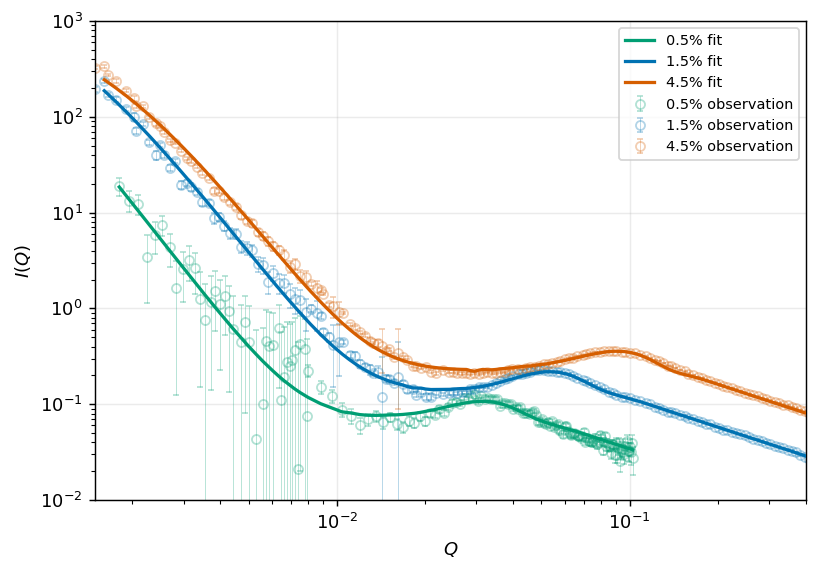

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 4.5))

for tags in zip(SAMPLE_TAGS, WEIGHTFRAC_TAGS):
    tag = tags[0]
    weightfrac = tags[1]
    label = tag.split("_")[0]
    obs = observations[tag]
    fit = fit_curves[tag]
    positive = np.isfinite(obs["I"]) & (obs["I"] > 0.0)
    ax.errorbar(
        obs["Q"][positive],
        obs["I"][positive],
        yerr=obs["err"][positive],
        fmt="o",
        ms=5.0,
        lw=0.5,
        capsize=1.5,
        color=COLORS[tag],
        markerfacecolor="none",
        alpha=0.3,
        label=f"{weightfrac}% observation",
    )
    ax.plot(
        fit["Q"],
        fit["I_fit"],
        color=COLORS[tag],
        lw=1.8,
        label=f"{weightfrac}% fit",
        zorder=10,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.5e-3, 4.0e-1)
ax.set_ylim(1e-2, 1e3)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()

COMPARISON_PLOT = OUTPUT_DIR / "55A_55B_55C_observations_and_model_fits.png"
fig.savefig(COMPARISON_PLOT)
print(f"[status] saved {COMPARISON_PLOT}")

## What is fitted and what is constrained

The nonlinear fit floats `mean_k`, `r_sigma_k`, `skewness`, `k_H_over_k`, and `b`. The intensity `scale` is also a fitted degree of freedom, but it is solved analytically at every nonlinear trial. All other saved quantities are derived from these six effective parameters.

Each sample has 149 fitted $I(Q)$ points. The low-$Q$ mask inverse length and the high-$Q$ $I(Q)\propto Q^{-1}$ amplitude are added as soft anchors. Because both anchors are extracted from the same scattering curve, they reinforce different $Q$ regions but are not independent experiments. Nominal weight fraction, chemical density, and coherent SLD are not used to fit the curve; they enter later as external consistency checks.

The high-$Q$ intensity coefficient fitted directly from the high-$Q$ portion of $I(Q)$ is denoted `i_highq_anchor`. The coupled-model prediction is denoted `i_highq_model`. Neither is the direct-space correlation function $C(r)$.


In [4]:
FLOATING_PARAMETER_NAMES = (
    "mean_k", "r_sigma_k", "skewness", "k_H_over_k", "b", "scale"
)
DERIVED_PARAMETER_NAMES = (
    "k_H", "p_H", "sigma_H_squared", "alpha_H", "kappa_H", "rho0"
)

print("Fit information map")
print("-" * 96)
print("Floating: " + ", ".join(FLOATING_PARAMETER_NAMES))
print("  scale is profiled analytically; the other five are nonlinear variables.")
print("Derived:  " + ", ".join(DERIVED_PARAMETER_NAMES))
print("External checks: nominal wt%, component mass densities, coherent SLD contrast")
print("-" * 96)
for tag in SAMPLE_TAGS:
    params = fit_parameters[tag]
    n_fit = len(fit_curves[tag]["Q"])
    i_highq_anchor = i_highq_anchor_from_intensity[tag]
    i_highq_model = params["highq_coefficient"]
    print(
        f"{tag}: N_fit={n_fit}, effective fit parameters=6, "
        f"nominal residual dof={n_fit-6}"
    )
    print(
        f"  mean_k={params['mean_k']:.6g}, r_sigma_k={params['r_sigma_k']:.6g}, "
        f"skewness={params['skewness']:.6g}, k_H/k={params['k_H_over_k']:.6g}, "
        f"b={params['b']:.6g}, scale={params['scale']:.6g}"
    )
    print(
        f"  i_highq_anchor={i_highq_anchor:.6g} A^-2 "
        "(fitted directly from high-Q I(Q), not from C(r))"
    )
    print(
        f"  i_highq_model={i_highq_model:.6g} A^-2 "
        f"(coupled model; model/anchor={i_highq_model/i_highq_anchor:.6g})"
    )


Fit information map
------------------------------------------------------------------------------------------------
Floating: mean_k, r_sigma_k, skewness, k_H_over_k, b, scale
  scale is profiled analytically; the other five are nonlinear variables.
Derived:  k_H, p_H, sigma_H_squared, alpha_H, kappa_H, rho0
External checks: nominal wt%, component mass densities, coherent SLD contrast
------------------------------------------------------------------------------------------------
55A_R0: N_fit=157, effective fit parameters=6, nominal residual dof=151
  mean_k=0.0194123, r_sigma_k=0.27, skewness=0.113521, k_H/k=0.0519927, b=0.00256518, scale=50.1527
  i_highq_anchor=0.00319125 A^-2 (fitted directly from high-Q I(Q), not from C(r))
  i_highq_model=0.0033688 A^-2 (coupled model; model/anchor=1.05564)
55B_R0: N_fit=149, effective fit parameters=6, nominal residual dof=143
  mean_k=0.0332441, r_sigma_k=0.27, skewness=1.05372, k_H/k=0.0794543, b=-0.795197, scale=36.7683
  i_highq_anchor=0.0

## Line-length density: without and with $p_H$

The random-wave density $\rho_0=\langle k^2\rangle/(3\pi)$ is the full unmasked line length per unit volume. The retained visible density is $p_H\rho_0$. Both are carried through the analysis because they answer different questions: $\rho_0$ represents all modeled polymer lines, while $p_H\rho_0$ represents only the lines retained by the heterogeneous mask.


In [5]:
# Chain contour length per unit volume and estimated PSSNa weight fractions.
# rho0 is the unmasked line-length density; p_H is the retained mask fraction.
# Assumptions: Q is in angstrom^-1, one PSSNa repeat contributes 0.25 nm
# of contour, repeat molar mass is 206.19 g/mol, and glycerol-d8 density is
# 1.371 g/cm^3 at 25 C. Weight fractions assume additive dilute-solution mass.
AVOGADRO = 6.02214076e23
PSSNA_REPEAT_MOLAR_MASS_G_PER_MOL = 206.19
PSSNA_CONTOUR_INCREMENT_NM = 0.25
GLYCEROL_D8_DENSITY_G_PER_CM3 = 1.371

def pssna_mass_concentration_g_per_cm3(length_density_nm_per_nm3):
    repeat_mass_g = PSSNA_REPEAT_MOLAR_MASS_G_PER_MOL / AVOGADRO
    mass_per_contour_nm = repeat_mass_g / PSSNA_CONTOUR_INCREMENT_NM
    return length_density_nm_per_nm3 * mass_per_contour_nm * 1.0e21


def approximate_weight_percent(polymer_g_per_cm3):
    return 100.0 * polymer_g_per_cm3 / (
        GLYCEROL_D8_DENSITY_G_PER_CM3 + polymer_g_per_cm3
    )


chain_length_density_results = {}

print("Chain contour-length density (assuming Q in angstrom^-1)")
print("-" * 78)
for tag in SAMPLE_TAGS:
    params = fit_parameters[tag]
    rho0 = params["rho0"]
    p_H = params["p_H"]
    retained_density = p_H * rho0
    unmasked_nm_per_nm3 = 100.0 * rho0
    retained_nm_per_nm3 = 100.0 * retained_density
    unmasked_concentration = pssna_mass_concentration_g_per_cm3(unmasked_nm_per_nm3)
    retained_concentration = pssna_mass_concentration_g_per_cm3(retained_nm_per_nm3)
    unmasked_weight_percent = approximate_weight_percent(unmasked_concentration)
    retained_weight_percent = approximate_weight_percent(retained_concentration)

    result = {
        "rho0_A^-2": rho0,
        "unmasked_nm_per_nm3": unmasked_nm_per_nm3,
        "p_H": p_H,
        "retained_A^-2": retained_density,
        "retained_nm_per_nm3": retained_nm_per_nm3,
        "retained_m^-2": 1.0e20 * retained_density,
        "chain_mm_per_um^3": 1.0e5 * retained_density,
        "unmasked_concentration_g_per_cm3": unmasked_concentration,
        "retained_concentration_g_per_cm3": retained_concentration,
        "unmasked_weight_percent": unmasked_weight_percent,
        "retained_weight_percent": retained_weight_percent,
    }
    chain_length_density_results[tag] = result

    print(f"{tag}:")
    print(f"  unmasked rho0          = {rho0:.8g} A^-2")
    print(f"                         = {unmasked_nm_per_nm3:.8g} nm/nm^3")
    print(f"  retained fraction p_H  = {p_H:.8g}")
    print(f"  retained length/volume = {retained_density:.8g} A^-2")
    print(f"                         = {result['retained_nm_per_nm3']:.8g} nm/nm^3")
    print(f"                         = {result['retained_m^-2']:.8g} m^-2")
    print(f"                         = {result['chain_mm_per_um^3']:.6g} mm per um^3")
    print(f"  estimated PSSNa concentration (unmasked) = {unmasked_concentration:.6g} g/cm^3")
    print(f"  estimated PSSNa concentration (retained) = {retained_concentration:.6g} g/cm^3")
    print(f"  estimated PSSNa weight fraction (unmasked) = {unmasked_weight_percent:.6g} wt%")
    print(f"  estimated PSSNa weight fraction (retained) = {retained_weight_percent:.6g} wt%")

print("-" * 78)
reference_density = chain_length_density_results["55A_R0"]["retained_A^-2"]
for tag in SAMPLE_TAGS[1:]:
    density_ratio = chain_length_density_results[tag]["retained_A^-2"] / reference_density
    print(f"{tag} / 55A_R0 retained chain-length density = {density_ratio:.6g}")

# Invert the independently known sample weight fractions to estimate how much
# unresolved chemical contour is represented by each unit of fitted line length.
# A factor > 1 means the true backbone contour is longer than the fitted smooth line.
NOMINAL_PSSNA_WEIGHT_PERCENT = {"55A_R0": 0.5, "55B_R0": 1.5, "55C_R0": 4.5}

print("\nUnresolved backbone-contour estimate from nominal sample weight fractions")
print("-" * 78)
for tag in SAMPLE_TAGS:
    nominal_wt_percent = NOMINAL_PSSNA_WEIGHT_PERCENT[tag]
    nominal_mass_fraction = nominal_wt_percent / 100.0
    target_concentration = (
        nominal_mass_fraction / (1.0 - nominal_mass_fraction)
        * GLYCEROL_D8_DENSITY_G_PER_CM3
    )
    result = chain_length_density_results[tag]

    print(f"{tag}: nominal={nominal_wt_percent:.3g} wt%, target={target_concentration:.6g} g/cm^3")
    for basis in ("unmasked", "retained"):
        model_concentration = result[f"{basis}_concentration_g_per_cm3"]
        contour_factor = target_concentration / model_concentration
        effective_repeat_advance_nm = PSSNA_CONTOUR_INCREMENT_NM / contour_factor
        result[f"{basis}_unresolved_contour_factor"] = contour_factor
        result[f"{basis}_effective_repeat_advance_nm"] = effective_repeat_advance_nm
        print(
            f"  {basis:8s}: true contour / fitted line = {contour_factor:.6g}; "
            f"effective repeat advance = {effective_repeat_advance_nm:.6g} nm"
        )

Chain contour-length density (assuming Q in angstrom^-1)
------------------------------------------------------------------------------
55A_R0:
  unmasked rho0          = 4.2850055e-05 A^-2
                         = 0.0042850055 nm/nm^3
  retained fraction p_H  = 0.49897664
  retained length/volume = 2.1381177e-05 A^-2
                         = 0.0021381177 nm/nm^3
                         = 2.1381177e+15 m^-2
                         = 2.13812 mm per um^3
  estimated PSSNa concentration (unmasked) = 0.00586851 g/cm^3
  estimated PSSNa concentration (retained) = 0.00292825 g/cm^3
  estimated PSSNa weight fraction (unmasked) = 0.426222 wt%
  estimated PSSNa weight fraction (retained) = 0.21313 wt%
55B_R0:
  unmasked rho0          = 0.00012509116 A^-2
                         = 0.012509116 nm/nm^3
  retained fraction p_H  = 0.78675052
  retained length/volume = 9.8415538e-05 A^-2
                         = 0.0098415538 nm/nm^3
                         = 9.8415538e+15 m^-2
             

## Curve-length-density scaling with the fitted length scale

Define the fitted characteristic length as $\ell_0=1/k_0$, where $k_0$ is `mean_k`. The log-log plot below compares the full fitted curve-length density $\rho_0$ and the mask-retained density $p_H\rho_0$ across 55A, 55B, and 55C. Power laws $\rho_L\propto\ell_0^n$ are fitted to both series, and the geometrical random-wave expectation $\rho_0\propto k_0^2\propto\ell_0^{-2}$ is shown as a reference.

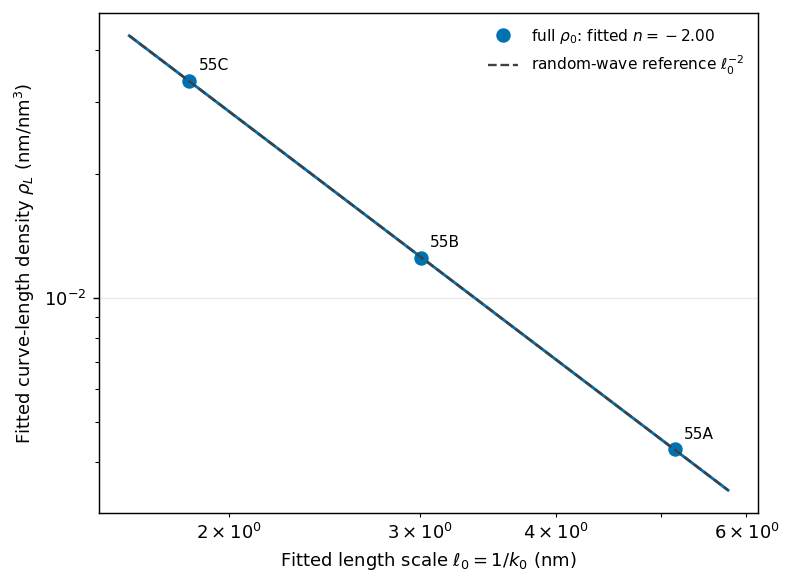

full rho0 scaling exponent       = -2.00018
retained p_H*rho0 exponent      = -2.63242
[status] saved output\yyw\55A_55B_55C_length_density_scaling.png


In [6]:
scaling_length_nm = np.array([
    0.1 / fit_parameters[tag]["mean_k"] for tag in SAMPLE_TAGS
])
scaling_rho0_nm2 = np.array([
    100.0 * chain_length_density_results[tag]["rho0_A^-2"] for tag in SAMPLE_TAGS
])
scaling_retained_nm2 = np.array([
    100.0 * chain_length_density_results[tag]["retained_A^-2"] for tag in SAMPLE_TAGS
])

def fit_scaling_power(length_nm, density_nm2):
    exponent, log_prefactor = np.polyfit(np.log(length_nm), np.log(density_nm2), 1)
    return float(exponent), float(np.exp(log_prefactor))

rho0_exponent, rho0_prefactor = fit_scaling_power(scaling_length_nm, scaling_rho0_nm2)
retained_exponent, retained_prefactor = fit_scaling_power(
    scaling_length_nm, scaling_retained_nm2
)

length_grid_nm = np.geomspace(
    0.88 * np.min(scaling_length_nm),
    1.12 * np.max(scaling_length_nm),
    200,
)
reference_length_nm = np.exp(np.mean(np.log(scaling_length_nm)))
reference_density_nm2 = np.exp(np.mean(np.log(scaling_rho0_nm2)))
inverse_square_reference = reference_density_nm2 * (
    length_grid_nm / reference_length_nm
) ** -2.0

fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.loglog(
    scaling_length_nm,
    scaling_rho0_nm2,
    "o",
    color="#0072B2",
    markersize=7,
    label=rf"full $\rho_0$: fitted $n={rho0_exponent:.2f}$",
)
ax.loglog(
    length_grid_nm,
    rho0_prefactor * length_grid_nm**rho0_exponent,
    "-",
    color="#0072B2",
    linewidth=1.6,
)
# ax.loglog(
#     scaling_length_nm,
#     scaling_retained_nm2,
#     "s",
#     color="#D55E00",
#     markersize=6.5,
#     label=rf"retained $p_H\rho_0$: fitted $n={retained_exponent:.2f}$",
# )
# ax.loglog(
#     length_grid_nm,
#     retained_prefactor * length_grid_nm**retained_exponent,
#     "-",
#     color="#D55E00",
#     linewidth=1.6,
# )
ax.loglog(
    length_grid_nm,
    inverse_square_reference,
    "--",
    color="0.25",
    linewidth=1.3,
    label=r"random-wave reference $\ell_0^{-2}$",
)

for tag, length_nm, density_nm2 in zip(SAMPLE_TAGS, scaling_length_nm, scaling_rho0_nm2):
    ax.annotate(
        tag.split("_")[0],
        (length_nm, density_nm2),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=8.5,
    )

ax.set_xlabel(r"Fitted length scale $\ell_0=1/k_0$ (nm)")
ax.set_ylabel(r"Fitted curve-length density $\rho_L$ (nm/nm$^3$)")
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()

SCALING_PLOT = OUTPUT_DIR / "55A_55B_55C_length_density_scaling.png"
fig.savefig(SCALING_PLOT, bbox_inches="tight")
plt.show()

print(f"full rho0 scaling exponent       = {rho0_exponent:.6g}")
print(f"retained p_H*rho0 exponent      = {retained_exponent:.6g}")
print(f"[status] saved {SCALING_PLOT}")

## Chemical inputs, coherent contrast, and area estimates

The coherent neutron scattering lengths of hydrogenated PSSNa (`C8H7NaO3S`) and glycerol-d8 (`C3D8O3`) define the excess SLD $\Delta\rho$. The absolute intensity scale gives an effective contrast area through

$$\mathrm{scale}=10^8(\Delta\rho\,A_\perp)^2,$$

where the factor $10^8$ converts the geometrical line intensity from inverse angstroms to inverse centimetres. The experimental intensity is in `cm^-1` and $Q$ is in `angstrom^-1`. A second area follows from volume closure, $A_{\rm nominal}=\phi_{\rm nominal}/\rho_L$, evaluated both with $\rho_L=\rho_0$ and with $\rho_L=p_H\rho_0$. A third molecular reference is the dry chemical-packing area $V_{\rm repeat}/l_{\rm repeat}$.

The directly fitted intensity anchor is `i_highq_anchor`, obtained from $I_{\rm highQ}(Q)\simeq i_{\rm highq}/Q$. The coupled model predicts `i_highq_model = scale * pi * p_H * rho0`. These names deliberately avoid a capital $C$, which is reserved for the direct-space correlation $C(r)$.

In [7]:
# Bound coherent neutron scattering lengths from the NIST NCNR table (fm).
COHERENT_B_FM = {
    "H": -3.7390,
    "D": 6.671,
    "C": 6.6460,
    "O": 5.803,
    "Na": 3.63,
    "S": 2.847,
}
PSSNA_REPEAT_ATOMS = {"C": 8, "H": 7, "Na": 1, "O": 3, "S": 1}
GLYCEROL_D8_ATOMS = {"C": 3, "D": 8, "O": 3}
GLYCEROL_D8_MOLAR_MASS_G_PER_MOL = 100.14
PSSNA_DRY_SLD_A_INV2 = 2.248e-6
FM_TO_ANGSTROM = 1.0e-5
ANGSTROM_INV_TO_CM_INV = 1.0e8


def molecular_coherent_b_fm(composition):
    return sum(count * COHERENT_B_FM[element] for element, count in composition.items())


def molecular_volume_A3(molar_mass_g_per_mol, density_g_per_cm3):
    return molar_mass_g_per_mol / (density_g_per_cm3 * AVOGADRO) * 1.0e24


pssna_repeat_b_fm = molecular_coherent_b_fm(PSSNA_REPEAT_ATOMS)
glycerol_d8_b_fm = molecular_coherent_b_fm(GLYCEROL_D8_ATOMS)
glycerol_d8_volume_A3 = molecular_volume_A3(
    GLYCEROL_D8_MOLAR_MASS_G_PER_MOL,
    GLYCEROL_D8_DENSITY_G_PER_CM3,
)
glycerol_d8_sld_A_inv2 = (
    glycerol_d8_b_fm * FM_TO_ANGSTROM / glycerol_d8_volume_A3
)
pssna_repeat_volume_A3 = (
    pssna_repeat_b_fm * FM_TO_ANGSTROM / PSSNA_DRY_SLD_A_INV2
)
pssna_implied_dry_density_g_per_cm3 = (
    PSSNA_REPEAT_MOLAR_MASS_G_PER_MOL
    / (AVOGADRO * pssna_repeat_volume_A3 * 1.0e-24)
)
pssna_dry_chemical_area_nm2 = (
    pssna_repeat_volume_A3 * 1.0e-3 / PSSNA_CONTOUR_INCREMENT_NM
)
delta_sld_A_inv2 = PSSNA_DRY_SLD_A_INV2 - glycerol_d8_sld_A_inv2

print("Coherent neutron contrast")
print("-" * 78)
print(f"PSSNa repeat coherent b       = {pssna_repeat_b_fm:.6g} fm")
print(f"glycerol-d8 molecular b       = {glycerol_d8_b_fm:.6g} fm")
print(f"glycerol-d8 molecular volume  = {glycerol_d8_volume_A3:.6g} A^3")
print(f"glycerol-d8 coherent SLD      = {glycerol_d8_sld_A_inv2:.6g} A^-2")
print(f"PSSNa coherent SLD            = {PSSNA_DRY_SLD_A_INV2:.6g} A^-2")
print(f"PSSNa implied dry density     = {pssna_implied_dry_density_g_per_cm3:.6g} g/cm^3")
print(f"dry chemical-packing area     = {pssna_dry_chemical_area_nm2:.6g} nm^2")
print(f"PSSNa - glycerol-d8 contrast  = {delta_sld_A_inv2:.6g} A^-2")

absolute_scale_results = {}
print("\nCross-sectional-area and volume-fraction closure")
print("I in cm^-1; Q in angstrom^-1")
print("-" * 96)
for tag in SAMPLE_TAGS:
    params = fit_parameters[tag]
    fitted_scale = params["scale"]
    contrast_amplitude = np.sqrt(fitted_scale / ANGSTROM_INV_TO_CM_INV)
    effective_area_A2 = contrast_amplitude / abs(delta_sld_A_inv2)
    effective_area_nm2 = effective_area_A2 / 100.0
    effective_radius_nm = np.sqrt(effective_area_nm2 / np.pi)

    nominal_mass_fraction = NOMINAL_PSSNA_WEIGHT_PERCENT[tag] / 100.0
    nominal_polymer_g_per_cm3 = (
        nominal_mass_fraction / (1.0 - nominal_mass_fraction)
        * GLYCEROL_D8_DENSITY_G_PER_CM3
    )
    nominal_polymer_to_solvent_volume_ratio = (
        nominal_polymer_g_per_cm3 / pssna_implied_dry_density_g_per_cm3
    )
    nominal_polymer_volume_fraction = (
        nominal_polymer_to_solvent_volume_ratio
        / (1.0 + nominal_polymer_to_solvent_volume_ratio)
    )
    i_highq_without_pH = fitted_scale * np.pi * params["rho0"]
    i_highq_with_pH = i_highq_without_pH * params["p_H"]
    i_highq_anchor = i_highq_anchor_from_intensity[tag]

    sample_result = {
        "fitted_scale": fitted_scale,
        "effective_area_nm2": effective_area_nm2,
        "effective_radius_nm": effective_radius_nm,
        "nominal_polymer_volume_fraction": nominal_polymer_volume_fraction,
        "i_highq_without_pH_A^-2": i_highq_without_pH,
        "i_highq_with_pH_A^-2": i_highq_with_pH,
        "i_highq_anchor_A^-2": i_highq_anchor,
    }
    absolute_scale_results[tag] = sample_result

    print(
        f"{tag}: nominal phi={nominal_polymer_volume_fraction:.6g}; "
        f"scale-derived A_eff={effective_area_nm2:.6g} nm^2 "
        f"(r_eff={effective_radius_nm:.6g} nm)"
    )
    print(
        f"  i_highq_anchor from high-Q I(Q)={i_highq_anchor:.6g} A^-2 "
        "(not C(r))"
    )
    print(
        f"  i_highq_model: without p_H={i_highq_without_pH:.6g} A^-2; "
        f"with p_H={i_highq_with_pH:.6g} A^-2; "
        f"with-p_H/anchor={i_highq_with_pH/i_highq_anchor:.6g}"
    )
    for basis in ("unmasked", "retained"):
        basis_label = "without p_H" if basis == "unmasked" else "with p_H"
        line_density_nm_inv2 = chain_length_density_results[tag][
            f"{basis}_nm_per_nm3"
        ]
        density_matched_area_nm2 = (
            nominal_polymer_volume_fraction / line_density_nm_inv2
        )
        predicted_scale = ANGSTROM_INV_TO_CM_INV * (
            delta_sld_A_inv2 * density_matched_area_nm2 * 100.0
        ) ** 2
        scale_ratio = fitted_scale / predicted_scale
        effective_volume_fraction = line_density_nm_inv2 * effective_area_nm2
        volume_fraction_ratio = effective_volume_fraction / nominal_polymer_volume_fraction
        effective_mass_fraction = (
            effective_volume_fraction * pssna_implied_dry_density_g_per_cm3
            / (
                effective_volume_fraction * pssna_implied_dry_density_g_per_cm3
                + (1.0 - effective_volume_fraction) * GLYCEROL_D8_DENSITY_G_PER_CM3
            )
        )
        sample_result[f"{basis}_density_matched_area_nm2"] = density_matched_area_nm2
        sample_result[f"{basis}_predicted_scale"] = predicted_scale
        sample_result[f"{basis}_fitted_over_predicted_scale"] = scale_ratio
        sample_result[f"{basis}_effective_volume_fraction"] = effective_volume_fraction
        sample_result[f"{basis}_effective_over_nominal_volume_fraction"] = volume_fraction_ratio
        sample_result[f"{basis}_effective_implied_weight_percent"] = 100.0 * effective_mass_fraction
        print(
            f"  {basis_label:12s}: rho_L={line_density_nm_inv2:.6g} nm^-2; "
            f"A_nominal={density_matched_area_nm2:.6g} nm^2; "
            f"rho_L*A_eff={effective_volume_fraction:.6g}"
        )
        print(
            f"                  phi_eff/phi_nominal={volume_fraction_ratio:.6g}; "
            f"A_eff-implied={100*effective_mass_fraction:.6g} wt%; "
            f"scale_fit/scale_nominal={scale_ratio:.6g}"
        )

Coherent neutron contrast
------------------------------------------------------------------------------
PSSNa repeat coherent b       = 50.881 fm
glycerol-d8 molecular b       = 90.715 fm
glycerol-d8 molecular volume  = 121.288 A^3
glycerol-d8 coherent SLD      = 7.47928e-06 A^-2
PSSNa coherent SLD            = 2.248e-06 A^-2
PSSNa implied dry density     = 1.51272 g/cm^3
dry chemical-packing area     = 0.905356 nm^2
PSSNa - glycerol-d8 contrast  = -5.23128e-06 A^-2

Cross-sectional-area and volume-fraction closure
I in cm^-1; Q in angstrom^-1
------------------------------------------------------------------------------------------------
55A_R0: nominal phi=0.00453371; scale-derived A_eff=1.35375 nm^2 (r_eff=0.656439 nm)
  i_highq_anchor from high-Q I(Q)=0.00319125 A^-2 (not C(r))
  i_highq_model: without p_H=0.00675143 A^-2; with p_H=0.0033688 A^-2; with-p_H/anchor=1.05564
  without p_H : rho_L=0.00428501 nm^-2; A_nominal=1.05804 nm^2; rho_L*A_eff=0.00580083
                  phi_ef

## Nominal-composition SLD distribution

With additive component volumes, a nominal polymer mass fraction $w$ gives

$$\phi_p=\frac{w/\rho_p}{w/\rho_p+(1-w)/\rho_s}.$$

At molecular resolution the simplest two-component estimate is

$$P(\rho)=(1-\phi_p)\,\delta(\rho-\rho_s)+\phi_p\,\delta(\rho-\rho_p).$$

Its mean is $\bar\rho=(1-\phi_p)\rho_s+\phi_p\rho_p$ and its fluctuation variance is $\phi_p(1-\phi_p)(\rho_p-\rho_s)^2$. This is a limiting binary-mixture description: hydration, counterion partitioning, and finite-resolution averaging would broaden or shift the peaks. Nominal concentration determines these one-point statistics, but not their spatial correlations; the latter are supplied by the random-wave line model.


Nominal-composition coherent-SLD distribution
----------------------------------------------------------------------------------------
55A_R0 (0.5 wt% PSSNa):
  polymer volume fraction       = 0.00453371 (0.4534 vol%)
  P(rho_s=7.47928e-06 A^-2) = 0.995466
  P(rho_p=2.248e-06 A^-2) = 0.00453371
  mean coherent SLD             = 7.45556e-06 A^-2
  RMS local SLD fluctuation     = 3.51438e-07 A^-2
  without p_H : A_nominal=1.05804 nm^2; A_eff/A_nominal=1.27949; phi_eff=0.00580083; phi_eff/phi_nominal=1.27949; inferred=0.639661 wt%; scale ratio=1.63709
  with p_H    : A_nominal=2.12042 nm^2; A_eff/A_nominal=0.638436; phi_eff=0.00289448; phi_eff/phi_nominal=0.638436; inferred=0.319272 wt%; scale ratio=0.4076
55B_R0 (1.5 wt% PSSNa):
  polymer volume fraction       = 0.0136139 (1.361 vol%)
  P(rho_s=7.47928e-06 A^-2) = 0.986386
  P(rho_p=2.248e-06 A^-2) = 0.0136139
  mean coherent SLD             = 7.40806e-06 A^-2
  RMS local SLD fluctuation     = 6.06209e-07 A^-2
  without p_H : A_nominal=1

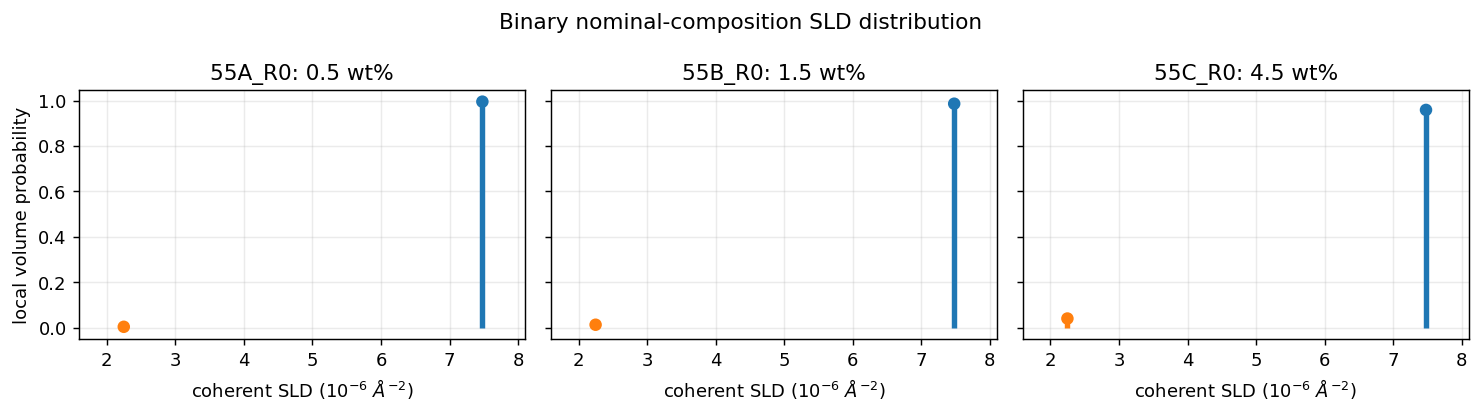


Use the without-p_H row for total-polymer volume closure. The with-p_H row
shows the alternative result if only mask-retained visible line is counted.


In [8]:
# Estimate the local coherent-SLD distribution from the nominal compositions.
nominal_sld_results = {}
fig, axes = plt.subplots(1, len(SAMPLE_TAGS), figsize=(11.5, 3.2), sharey=True)

print("Nominal-composition coherent-SLD distribution")
print("-" * 88)
for ax, tag in zip(axes, SAMPLE_TAGS):
    w = NOMINAL_PSSNA_WEIGHT_PERCENT[tag] / 100.0
    polymer_specific_volume = w / pssna_implied_dry_density_g_per_cm3
    solvent_specific_volume = (1.0 - w) / GLYCEROL_D8_DENSITY_G_PER_CM3
    phi_p = polymer_specific_volume / (polymer_specific_volume + solvent_specific_volume)

    mean_sld = (
        phi_p * PSSNA_DRY_SLD_A_INV2
        + (1.0 - phi_p) * glycerol_d8_sld_A_inv2
    )
    sld_variance = phi_p * (1.0 - phi_p) * delta_sld_A_inv2**2
    sld_rms = np.sqrt(sld_variance)

    nominal_sld_results[tag] = {
        "polymer_volume_fraction": phi_p,
        "mean_sld_A^-2": mean_sld,
        "sld_rms_A^-2": sld_rms,
    }

    print(f"{tag} ({100*w:.3g} wt% PSSNa):")
    print(f"  polymer volume fraction       = {phi_p:.6g} ({100*phi_p:.4g} vol%)")
    print(f"  P(rho_s={glycerol_d8_sld_A_inv2:.6g} A^-2) = {1-phi_p:.6g}")
    print(f"  P(rho_p={PSSNA_DRY_SLD_A_INV2:.6g} A^-2) = {phi_p:.6g}")
    print(f"  mean coherent SLD             = {mean_sld:.6g} A^-2")
    print(f"  RMS local SLD fluctuation     = {sld_rms:.6g} A^-2")
    for basis in ("unmasked", "retained"):
        basis_label = "without p_H" if basis == "unmasked" else "with p_H"
        nominal_area = absolute_scale_results[tag][f"{basis}_density_matched_area_nm2"]
        area_ratio = absolute_scale_results[tag]["effective_area_nm2"] / nominal_area
        effective_phi = absolute_scale_results[tag][f"{basis}_effective_volume_fraction"]
        phi_ratio = absolute_scale_results[tag][f"{basis}_effective_over_nominal_volume_fraction"]
        inferred_wt = absolute_scale_results[tag][f"{basis}_effective_implied_weight_percent"]
        scale_ratio = absolute_scale_results[tag][f"{basis}_fitted_over_predicted_scale"]
        print(
            f"  {basis_label:12s}: A_nominal={nominal_area:.6g} nm^2; "
            f"A_eff/A_nominal={area_ratio:.6g}; phi_eff={effective_phi:.6g}; "
            f"phi_eff/phi_nominal={phi_ratio:.6g}; inferred={inferred_wt:.6g} wt%; "
            f"scale ratio={scale_ratio:.6g}"
        )

    sld_points = np.array([PSSNA_DRY_SLD_A_INV2, glycerol_d8_sld_A_inv2]) * 1.0e6
    probabilities = np.array([phi_p, 1.0 - phi_p])
    ax.vlines(sld_points, 0.0, probabilities, color=["C1", "C0"], lw=3)
    ax.scatter(sld_points, probabilities, color=["C1", "C0"], s=35, zorder=3)
    ax.set_title(f"{tag}: {100*w:.1f} wt%")
    ax.set_xlabel(r"coherent SLD ($10^{-6}$ $\AA^{-2}$)")
    ax.set_xlim(1.6, 8.1)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("local volume probability")
fig.suptitle("Binary nominal-composition SLD distribution")
fig.tight_layout()
plt.show()

print("\nUse the without-p_H row for total-polymer volume closure. The with-p_H row")
print("shows the alternative result if only mask-retained visible line is counted.")


### Cross-section estimates and consistency assessment

Four numerical area estimates are displayed: (1) the absolute-intensity/SLD effective area, (2) nominal volume fraction divided by $\rho_0$ without $p_H$, (3) nominal volume fraction divided by $p_H\rho_0$ with $p_H$, and (4) the dry chemical-packing reference $V_{\rm repeat}/l_{\rm repeat}$. These belong to three physical families: neutron contrast, composition closure, and molecular packing. The coupled-model coefficient `i_highq_model` is linked to the same fitted scale by $i_{\rm highq}=\mathrm{scale}\,\pi p_H\rho_0$ and is therefore not a fifth independent area measurement. The separately fitted `i_highq_anchor` comes directly from the high-$Q$ portion of $I(Q)$, but it still uses the same scattering dataset rather than an independent experiment.

For total-polymer closure, the result without $p_H$ is the primary comparison. The cells above report $\phi_{\rm eff}/\phi_{\rm nominal}$ for 55A, 55B, and 55C, where $\phi_{\rm eff}=\rho_L A_{\rm eff}$. The rows including $p_H$ ask how much volume is represented only by the retained visible line. Because intensity depends on the square of $\Delta\rho A_{\rm eff}$, a modest area or effective-contrast error produces roughly twice that relative error in scale.

Each fit is numerically overdetermined by its many fitted points and six effective parameters, but not every physical check is independent. The two soft anchors come from the same $I(Q)$ data, and the two nominal-area rows differ only by the choice of line-density basis. Hydration, counterion partitioning, a diffuse radial SLD profile, concentration uncertainty, absolute-calibration uncertainty, and covariance between line density and scale can all shift the apparent closure. The two-delta SLD distribution is therefore a dry-polymer/solvent limiting model rather than a resolved radial SLD profile.


## Orientation correlations of the fitted line fields

Following `../rw_line_tcorr.ipynb` and `cf_compare_pecora.ipynb`, the first panel compares the exact signed tangent correlation $K_T^{\rm raw}=M_T/M_J$. The second compares the line-density-weighted nematic correlation $K_2=M_2/M_J$ after subtracting `K_2_inf_sampled`. Each sample uses its fitted maximum-entropy spectrum and the common dimensionless axis $r k_{\rm eff}$.


In [9]:
ORIENTATION_NUM_K_MODES = 2**13
ORIENTATION_N_SAMP = 2**20
ORIENTATION_RANDOM_SEED = 12345
ORIENTATION_X_GRID = np.geomspace(1.0e-3, 60.0, 360)
ORIENTATION_PROGRESS = True
ORIENTATION_LABELS = {
    "55A_R0": "55A (0.5 wt%)",
    "55B_R0": "55B (1.5 wt%)",
    "55C_R0": "55C (4.5 wt%)",
}

orientation_results = {}
for tag in SAMPLE_TAGS:
    params = fit_parameters[tag]
    result = cf.compute_fit_orientation_correlations(
        params,
        x_grid=ORIENTATION_X_GRID,
        num_k_modes=ORIENTATION_NUM_K_MODES,
        n_samp=ORIENTATION_N_SAMP,
        random_seed=ORIENTATION_RANDOM_SEED,
        progress=ORIENTATION_PROGRESS,
    )
    orientation_results[tag] = result
    data_path = OUTPUT_DIR / f"{tag}_orientation_correlations.npz"
    np.savez(
        data_path,
        **result,
        mean_k=params["mean_k"],
        r_sigma_k=params["r_sigma_k"],
        skewness=params["skewness"],
        num_k_modes=ORIENTATION_NUM_K_MODES,
        n_samp=ORIENTATION_N_SAMP,
        random_seed=ORIENTATION_RANDOM_SEED,
    )
    print(
        f"[orientation] {ORIENTATION_LABELS[tag]}: k_eff={result['k_eff']:.6g} A^-1, "
        f"K_T_raw(r_min)={result['K_T_raw'][0]:.6g}, "
        f"K_2(r_min)={result['K_2_sampled'][0]:.6g}, "
        f"K_2_inf_sampled={result['K_2_inf_sampled']:.6g}; saved {data_path}"
    )


K_2 direct_12d: 18/360 r values (6.0s)
K_2 direct_12d: 36/360 r values (11.1s)
K_2 direct_12d: 54/360 r values (15.6s)
K_2 direct_12d: 72/360 r values (20.0s)
K_2 direct_12d: 90/360 r values (24.3s)
K_2 direct_12d: 108/360 r values (29.0s)
K_2 direct_12d: 126/360 r values (33.4s)
K_2 direct_12d: 144/360 r values (37.5s)
K_2 direct_12d: 162/360 r values (41.7s)
K_2 direct_12d: 180/360 r values (46.0s)
K_2 direct_12d: 198/360 r values (50.2s)
K_2 direct_12d: 216/360 r values (54.6s)
K_2 direct_12d: 234/360 r values (58.7s)
K_2 direct_12d: 252/360 r values (62.8s)
K_2 direct_12d: 270/360 r values (67.0s)
K_2 direct_12d: 288/360 r values (71.3s)
K_2 direct_12d: 306/360 r values (75.5s)
K_2 direct_12d: 324/360 r values (79.7s)
K_2 direct_12d: 342/360 r values (83.9s)
K_2 direct_12d: 360/360 r values (88.3s)
[orientation] 55A (0.5 wt%): k_eff=0.0201081 A^-1, K_T_raw(r_min)=1.00001, K_2(r_min)=0.999999, K_2_inf_sampled=0.000784943; saved output\yyw\55A_R0_orientation_correlations.npz
K_2 dire

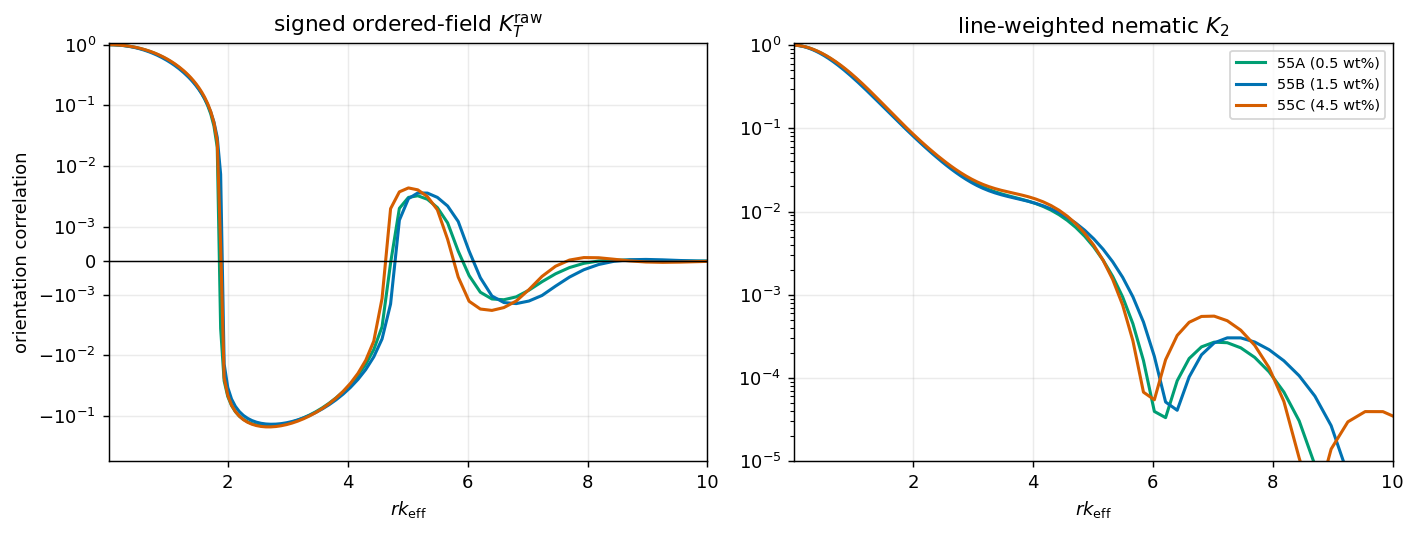

[status] saved output\yyw\yyw_orientation_correlations.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharex=True, sharey=False)

for tag in SAMPLE_TAGS:
    result = orientation_results[tag]
    axes[0].plot(
        result["r_k_eff"], result["K_T_raw"],
        color=COLORS[tag], lw=1.7, label=ORIENTATION_LABELS[tag],
    )
    axes[1].plot(
        result["r_k_eff"], result["K_2"] - result["K_2_inf_sampled"],
        color=COLORS[tag], lw=1.7, label=ORIENTATION_LABELS[tag],
    )

for ax in axes:
    ax.axhline(0.0, color="black", lw=0.8)
    # ax.axhline(1.0, color="0.5", lw=0.7, ls="--")
    ax.set_xlim(ORIENTATION_X_GRID[0], ORIENTATION_X_GRID[-1])
    ax.set_xlabel(r"$r k_{\rm eff}$")
axes[0].set_ylabel("orientation correlation")
axes[0].set_title(r"signed ordered-field $K_T^{\rm raw}$")
axes[0].set_yscale("symlog", linthresh=0.001, linscale=0.5)
axes[0].set_ylim(-0.55, 1.05)
axes[0].set_xlim(0.01, 10.0)
axes[1].set_title(r"line-weighted nematic $K_2$")
axes[1].legend(fontsize=8, loc="best")
axes[1].set_yscale("log")
axes[1].set_ylim(0.00001, 1.05)
fig.tight_layout()
ORIENTATION_PLOT = OUTPUT_DIR / "yyw_orientation_correlations.png"
fig.savefig(ORIENTATION_PLOT, bbox_inches="tight")
plt.show()
print(f"[status] saved {ORIENTATION_PLOT}")


## Static 3D renderings with a common box size

The fitted physical mask length is $L_H=1/k_H$. Since the renderer input is the ratio `box_size / mask_length`, maintaining the same physical box size for all samples, using 55C as the reference, requires

$$R_x = R_{55C}\,\frac{L_{H,55C}}{L_{H,x}} = R_{55C}\,\frac{k_{H,x}}{k_{H,55C}}.$$

This physical-$k_H$ scaling is applied to both the lateral ratio (15.0 for 55C) and thickness ratio (0.8 for 55C). The rendered tube is assigned a circular cross-section with

$$r_{\rm eff}=\sqrt{A_{\rm eff}/\pi},$$

so its actual physical cross-sectional area is the intensity-derived $A_{\rm eff}$ for each sample. Since the renderer specifies tube radius as a fraction of the visual lateral box size, the required fraction is $r_{\rm eff}/L_{\rm box,physical}$.

Two matched renderings are produced for every sample: the fitted heterogeneous mask and an unmasked result obtained by setting $p_H=1$ while retaining the fitted line-wavevector distribution, tube area, random seed, and common physical box. Rendering is off-screen and only static PNG files are produced.

In [11]:
RENDER_RANDOM_SEED = 114514
RENDER_K_LINE = 10.0
RENDER_NUM_LINE_MODES = 128
RENDER_NX = 150
RENDER_NY = 150
RENDER_NZ = 15
RENDER_55C_LATERAL_SIZE_OVER_MASK_LENGTH = 15.0
RENDER_55C_THICKNESS_OVER_MASK_LENGTH = 0.8
RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K = 10.0
RENDER_SHOW_MASK_BOUNDARY = False
RENDER_SHOW_BOX_BOUNDARY = True
RENDER_SHOW_REJECTED_LINES = False
RENDER_WINDOW_SIZE = (800, 800)
RENDER_WINDOW_FILL_FRACTION = 0.95
RENDER_INITIAL_VIEW = "normal"
RENDER_SCREENSHOT_SCALE = 3

REFERENCE_TAG = "55C_R0"
visual_k_H = {
    tag: RENDER_K_LINE * fit_parameters[tag]["k_H_over_k"]
    for tag in SAMPLE_TAGS
}
visual_mask_length = {tag: 1.0 / visual_k_H[tag] for tag in SAMPLE_TAGS}
ratio_scale = {
    tag: fit_parameters[tag]["k_H"] / fit_parameters[REFERENCE_TAG]["k_H"]
    for tag in SAMPLE_TAGS
}
render_lateral_ratio = {
    tag: RENDER_55C_LATERAL_SIZE_OVER_MASK_LENGTH * ratio_scale[tag]
    for tag in SAMPLE_TAGS
}
render_thickness_ratio = {
    tag: RENDER_55C_THICKNESS_OVER_MASK_LENGTH * ratio_scale[tag]
    for tag in SAMPLE_TAGS
}
physical_mask_length_nm = {
    tag: 0.1 / fit_parameters[tag]["k_H"]
    for tag in SAMPLE_TAGS
}
physical_lateral_size_nm = {
    tag: render_lateral_ratio[tag] * physical_mask_length_nm[tag]
    for tag in SAMPLE_TAGS
}
physical_thickness_nm = {
    tag: render_thickness_ratio[tag] * physical_mask_length_nm[tag]
    for tag in SAMPLE_TAGS
}
render_effective_area_nm2 = {
    tag: absolute_scale_results[tag]["effective_area_nm2"]
    for tag in SAMPLE_TAGS
}
render_effective_radius_nm = {
    tag: np.sqrt(render_effective_area_nm2[tag] / np.pi)
    for tag in SAMPLE_TAGS
}
render_line_tube_radius_fraction = {
    tag: render_effective_radius_nm[tag] / physical_lateral_size_nm[tag]
    for tag in SAMPLE_TAGS
}

for tag in SAMPLE_TAGS:
    visual_lateral_size = render_lateral_ratio[tag] * visual_mask_length[tag]
    visual_thickness = render_thickness_ratio[tag] * visual_mask_length[tag]
    print(
        f"[render settings] {tag}: visual_mask_length={visual_mask_length[tag]:.6g}, "
        f"lateral_ratio={render_lateral_ratio[tag]:.6g}, "
        f"thickness_ratio={render_thickness_ratio[tag]:.6g}, "
        f"visual_box=({visual_lateral_size:.6g}, {visual_lateral_size:.6g}, {visual_thickness:.6g})"
    )
    print(
        f"                  physical_mask_length={physical_mask_length_nm[tag]:.6g} nm, "
        f"physical_box=({physical_lateral_size_nm[tag]:.6g}, "
        f"{physical_lateral_size_nm[tag]:.6g}, {physical_thickness_nm[tag]:.6g}) nm"
    )
    print(
        f"                  A_eff={render_effective_area_nm2[tag]:.6g} nm^2, "
        f"r_eff={render_effective_radius_nm[tag]:.6g} nm, "
        f"tube diameter={2.0*render_effective_radius_nm[tag]:.6g} nm, "
        f"renderer radius fraction={render_line_tube_radius_fraction[tag]:.6g}"
    )

[render settings] 55A_R0: visual_mask_length=1.92335, lateral_ratio=4.89271, thickness_ratio=0.260944, visual_box=(9.41036, 9.41036, 0.501886)
                  physical_mask_length=99.1211 nm, physical_box=(484.97, 484.97, 25.8651) nm
                  A_eff=1.35375 nm^2, r_eff=0.656439 nm, tube diameter=1.31288 nm, renderer radius fraction=0.00135357
[render settings] 55B_R0: visual_mask_length=1.25859, lateral_ratio=12.7937, thickness_ratio=0.682332, visual_box=(16.102, 16.102, 0.858772)
                  physical_mask_length=37.9069 nm, physical_box=(484.97, 484.97, 25.8651) nm
                  A_eff=1.15912 nm^2, r_eff=0.607421 nm, tube diameter=1.21484 nm, renderer radius fraction=0.00125249
[render settings] 55C_R0: visual_mask_length=1.75766, lateral_ratio=15, thickness_ratio=0.8, visual_box=(26.3649, 26.3649, 1.40613)
                  physical_mask_length=32.3314 nm, physical_box=(484.97, 484.97, 25.8651) nm
                  A_eff=1.07189 nm^2, r_eff=0.584118 nm, tube diame

In [12]:
# render_results = {}

# for tag in SAMPLE_TAGS:
#     screenshot_path = OUTPUT_DIR / f"{tag}_fit_heterogeneous_common_box.png"
#     params = fit_parameters[tag]
#     preview = cf.render_fit_heterogeneous_preview(
#         params,
#         output_path=screenshot_path,
#         visual_k_line=RENDER_K_LINE,
#         line_k_distribution="max_entropy_radial",
#         line_r_sigma_k=params["r_sigma_k"],
#         line_k_distribution_params={"skewness": params["skewness"]},
#         random_seed=RENDER_RANDOM_SEED,
#         num_line_modes=RENDER_NUM_LINE_MODES,
#         nx=RENDER_NX,
#         ny=RENDER_NY,
#         nz=RENDER_NZ,
#         lateral_size_over_mask_length=render_lateral_ratio[tag],
#         thickness_over_mask_length=render_thickness_ratio[tag],
#         line_tube_radius_fraction=render_line_tube_radius_fraction[tag],
#         min_retained_line_length_over_k=RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K,
#         show_mask_boundary=RENDER_SHOW_MASK_BOUNDARY,
#         show_box_boundary=RENDER_SHOW_BOX_BOUNDARY,
#         show_rejected_lines=RENDER_SHOW_REJECTED_LINES,
#         window_size=RENDER_WINDOW_SIZE,
#         window_fill_fraction=RENDER_WINDOW_FILL_FRACTION,
#         initial_view=RENDER_INITIAL_VIEW,
#         screenshot_scale=RENDER_SCREENSHOT_SCALE,
#     )
#     render_results[tag] = preview
#     preview.plotter.close()
#     print(
#         f"[status] saved {screenshot_path}; "
#         f"retained cells={preview.retained_cells}, retained points={preview.retained_points}, "
#         f"A_eff={render_effective_area_nm2[tag]:.6g} nm^2, "
#         f"tube_diameter={2.0*render_effective_radius_nm[tag]:.6g} nm, "
#         f"physical_box=({physical_lateral_size_nm[tag]:.6g}, "
#         f"{physical_lateral_size_nm[tag]:.6g}, {physical_thickness_nm[tag]:.6g}) nm"
#     )

# unmasked_render_results = {}

# for tag in SAMPLE_TAGS:
#     screenshot_path = OUTPUT_DIR / f"{tag}_fit_unmasked_common_box.png"
#     unmasked_params = dict(fit_parameters[tag])
#     unmasked_params["p_H"] = 1.0
#     preview = cf.render_fit_heterogeneous_preview(
#         unmasked_params,
#         output_path=screenshot_path,
#         visual_k_line=RENDER_K_LINE,
#         line_k_distribution="max_entropy_radial",
#         line_r_sigma_k=unmasked_params["r_sigma_k"],
#         line_k_distribution_params={"skewness": unmasked_params["skewness"]},
#         random_seed=RENDER_RANDOM_SEED,
#         num_line_modes=RENDER_NUM_LINE_MODES,
#         nx=RENDER_NX,
#         ny=RENDER_NY,
#         nz=RENDER_NZ,
#         lateral_size_over_mask_length=render_lateral_ratio[tag],
#         thickness_over_mask_length=render_thickness_ratio[tag],
#         line_tube_radius_fraction=render_line_tube_radius_fraction[tag],
#         min_retained_line_length_over_k=RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K,
#         show_mask_boundary=False,
#         show_box_boundary=RENDER_SHOW_BOX_BOUNDARY,
#         show_rejected_lines=False,
#         window_size=RENDER_WINDOW_SIZE,
#         window_fill_fraction=RENDER_WINDOW_FILL_FRACTION,
#         initial_view=RENDER_INITIAL_VIEW,
#         screenshot_scale=RENDER_SCREENSHOT_SCALE,
#     )
#     unmasked_render_results[tag] = preview
#     preview.plotter.close()
#     print(
#         f"[status] saved {screenshot_path}; unmasked p_H={preview.p_H:.6g}, "
#         f"line cells={preview.retained_cells}, retained points={preview.retained_points}, "
#         f"A_eff={render_effective_area_nm2[tag]:.6g} nm^2, "
#         f"tube_diameter={2.0*render_effective_radius_nm[tag]:.6g} nm, "
#         f"physical_box=({physical_lateral_size_nm[tag]:.6g}, "
#         f"{physical_lateral_size_nm[tag]:.6g}, {physical_thickness_nm[tag]:.6g}) nm"
#     )

# for tag in SAMPLE_TAGS:
#     rendered_radius_nm = (
#         render_line_tube_radius_fraction[tag] * physical_lateral_size_nm[tag]
#     )
#     assert np.isclose(rendered_radius_nm, render_effective_radius_nm[tag])
#     assert np.isclose(np.pi * rendered_radius_nm**2, render_effective_area_nm2[tag])

# reference_lateral_size_nm = physical_lateral_size_nm[REFERENCE_TAG]
# reference_thickness_nm = physical_thickness_nm[REFERENCE_TAG]
# for tag in SAMPLE_TAGS:
#     assert np.isclose(physical_lateral_size_nm[tag], reference_lateral_size_nm)
#     assert np.isclose(physical_thickness_nm[tag], reference_thickness_nm)
# print("[status] verified: render tube areas equal A_eff and all boxes have the same physical dimensions")